# 逻辑回归实验

## Tips
- 实验前查看issue，同学们有问题可以在issue中提出，同时可以参考过往的问题完成此实验。
- 善用搜索引擎、AIGC工具拓展知识面。
## Issue
[【腾讯文档】逻辑回归-issues](
https://docs.qq.com/doc/DWmltZUxvRkNWY0FK)



## 数据处理

为了能够完成各种数据操作，我们需要某种方法来存储和操作数据。 通常，我们需要做两件重要的事：（1）获取数据；（2）将数据读入计算机后对其进行处理。 如果没有某种方法来存储数据，那么获取数据是没有意义的。

### 预处理

为了能用深度学习来解决现实世界的问题，我们经常从预处理原始数据开始， 而不是从那些准备好的张量格式数据开始。 在Python中常用的数据分析工具中，我们通常使用pandas软件包。 像庞大的Python生态系统中的许多其他扩展包一样，pandas可以与张量兼容。 这一节同学们讲使用pandas预处理原始数据，并将原始数据转换为张量格式的步骤。
#### 数据集读取

首先，需要尝试使用pandas中的`read_csv`函数读取train, val, test 这三个数据集（保留列名），同时在`utils.py`文件中，助教定义了一个名为`data_utils`的类，可以对读取的pd数据框进行简单的预处理。请尝试调用这个类的方法对于数据集进行进一步的处理。



In [29]:
import pandas as pd

# 数据集读取
train = pd.read_csv('data/train_sub.csv')
val = pd.read_csv('data/val_sub.csv')
test = pd.read_csv('data/test_sub.csv')

# 数据集预处理（使用 utils.py 中的 data_utils）
from utils import data_utils

train = data_utils(train).pipeline()
val = data_utils(val).pipeline()
test = data_utils(test).pipeline()

train.isnull().sum()

loanAmnt                 0
term                     0
interestRate             0
installment              0
grade                    0
employmentTitle          0
employmentLength      1728
homeOwnership            0
annualIncome             0
verificationStatus       0
issueDate                0
isDefault                0
purpose                  0
postCode                 0
regionCode               0
dti                      3
delinquency_2years       0
ficoRangeLow             0
ficoRangeHigh            0
openAcc                  0
pubRec                   0
pubRecBankruptcies       3
revolBal                 0
revolUtil               11
totalAcc                 0
initialListStatus        0
applicationType          0
earliesCreditLine        0
title                    0
policyCode               0
n0                     325
n1                     325
n2                     325
n3                     325
n4                     268
n5                     325
n6                     325
n

#### 处理缺失值
注意，上一个单元格输出的结果代表着每一列中缺失值的数量。为了处理缺失的数据，典型的方法包括插值法和删除法， 其中插值法用一个替代值弥补缺失值，而删除法则直接忽略缺失值。

首先，我们对于需要分析数据的input 和 output 的label，注意到`isDefault`是output的列名，所以首先我们需要丢弃掉所有`isDefault`列为NaN的行。

其次，对于其他input为空的行，我们需要使用同一列的均值来对 `NaN`进行填充。

##### data.mean()
用于计算数据框中每一列的均值。它可以帮助我们快速了解数据的中心趋势，特别是在处理缺失值时，我们可以用均值来填充NaN值。

##### pd.fillna()
是pandas中用于填充缺失值的方法。它允许我们用特定的值（如均值、中位数或其他值）来替换NaN。使用fillna()可以确保数据的完整性，避免在后续分析中因缺失值而导致的错误。

##### pd.dropna()
是pandas中用于删除缺失值的方法。它可以根据指定的条件（如某一列是否为NaN）来删除行或列。使用dropna()可以帮助我们清理数据集，确保分析时只使用完整的数据。

##### 例如，以下代码展示了如何使用这些方法：
```python
1. 计算均值并填充缺失值：
mean_value = data['column_name'].mean()
data['column_name'].fillna(mean_value, inplace=True)

2. 删除特定列中含有NaN的行：
data.dropna(subset=['column_name'], inplace=True)
```

<!-- ##### 通过这些方法，我们可以有效地处理数据中的缺失值，提高数据分析的准确性。 -->







In [30]:

# 过滤标签（isDefault列）为空的行
def filter_NA(data):
    """删除 isDefault 列为 NaN 的行"""
    return data.dropna(subset=['isDefault'])

# 填充其他输入特征的空值（用列均值）
def fill_mean(data):
    """用每列均值填充 NaN（排除 isDefault 列）"""
    # 复制一份避免警告
    data = data.copy()
    # 对每一列（除了 isDefault）填充均值
    for col in data.columns:
        if col != 'isDefault' and data[col].isnull().any():
            mean_val = data[col].mean()
            data[col].fillna(mean_val, inplace=True)
    return data

train, val, test = filter_NA(train), filter_NA(val), filter_NA(test)
train, val, test = fill_mean(train), fill_mean(val), fill_mean(test)


C:\Users\jing\AppData\Local\Temp\ipykernel_11812\3839400723.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(mean_val, inplace=True)


#### 转换为张量格式

按照之前的划分方式，我们把数据划分成input和label，其中，label为isDefault 列，input为其他列，并且转换为张量(tensor)的形式。


##### 1. Pandas数据选择和处理

###### 1.1 数据选择
在Pandas中，我们可以通过多种方式选择数据：

```python
# 假设我们有一个数据框df
# 1. 选择单列
column_data = df['column_name']  # 返回Series
# 2. 选择多列
columns_data = df[['column1', 'column2']]  # 返回DataFrame
```

###### 1.2 使用drop删除列
`drop()`是一个非常有用的方法，用于删除指定的行或列：

```python
# 删除列
df.drop('column_name', axis=1)  # axis=1表示删除列，axis=0表示删除行

# 示例：删除'isDefault'列
train_input = train.drop('isDefault', axis=1)
```

参数说明：
- `axis=1`: 表示删除列
- `axis=0`: 表示删除行
- `inplace=True`: 如果设置为True，则直接在原数据框上修改

###### 1.3 .values属性
`.values`属性用于将Pandas的DataFrame或Series转换为NumPy数组：

```python
# DataFrame转换为NumPy数组
numpy_array = df.values

# 示例
train_input_array = train_input.values  # 转换为numpy数组
```

##### 2. PyTorch张量转换

###### 2.1 创建张量
`torch.tensor()`用于创建PyTorch张量：

```python
# 基本语法
tensor = torch.tensor(data, dtype=torch.float32)

# 示例：将numpy数组转换为PyTorch张量
train_input = torch.tensor(train_input.values, dtype=torch.float32)
```

主要参数：
- `data`: 输入数据（可以是列表、NumPy数组等）
- `dtype`: 指定数据类型，常用的有：
  - `torch.float32`: 32位浮点数
  - `torch.int64`: 64位整数
  - `torch.bool`: 布尔值

##### 注意事项
1. 在转换为张量时，要确保数据类型正确
2. 对于分类问题的标签，通常使用`float32`或`long`类型
3. 在处理大数据集时，注意内存使用情况
4. 使用`drop()`时注意保存结果，因为默认不会修改原数据框



In [31]:
# 数据集划分
train_input = train.drop('isDefault', axis=1)
train_label = train['isDefault']

val_input = val.drop('isDefault', axis=1)
val_label = val['isDefault']

test_input = test.drop('isDefault', axis=1)
test_label = test['isDefault']

# 归一化（MinMaxScaler）
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_input = scaler.fit_transform(train_input)
val_input = scaler.transform(val_input)
test_input = scaler.transform(test_input)

# 将标签也转为 numpy 数组（方便之后转张量）
train_label = train_label.values
val_label = val_label.values
test_label = test_label.values

# 转换为 PyTorch 张量
import torch
train_input = torch.tensor(train_input, dtype=torch.float32)
train_label = torch.tensor(train_label, dtype=torch.float32).view(-1, 1)   # 变成列向量
val_input = torch.tensor(val_input, dtype=torch.float32)
val_label = torch.tensor(val_label, dtype=torch.float32).view(-1, 1)
test_input = torch.tensor(test_input, dtype=torch.float32)
test_label = torch.tensor(test_label, dtype=torch.float32).view(-1, 1)

### 构建Pytorch数据集

在pytorch中，提供了一种非常方便的数据读取机制，即`torch.utils.data.Dataset`类和`torch.utils.data.Dataloader`类，通过两种方式的组合，我们可以得到数据迭代器，在每次训练中，利用这个迭代器每次输出一组batch数据（即训练数据集中的一个子集）。

#### torch.utils.data.Dataset
torch.utils.data.Dataset代表着自定义数据集方法的类，用户可以继承这个类来自定义自己的数据集类，继承时，用户需要重载`__len__()`和 `__getitem__()`这两个方法

- `__len__()` 返回数据集的大小。 我们构建的数据集也是一个对象，这个方法希望像list,string,tuple等方法一样，可以直接获得对象的大小
- `__getitem__()`实现获得数据集中的某一个数据。 list,string,tuple可以通过一个索引来获得序列中的任意元素，通过实现``__getitem__()``，我们希望获得类似的功能。




In [32]:
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, *tensors):
        assert all(tensors[0].size(0) == t.size(0) for t in tensors), "Size mismatch"
        self.tensors = tensors

    def __getitem__(self, index):
        return tuple(t[index] for t in self.tensors)

    def __len__(self):
        return self.tensors[0].size(0)

train_dataset = MyDataset(train_input, train_label)
val_dataset = MyDataset(val_input, val_label)
test_dataset = MyDataset(test_input, test_label)



#### torch.utils.data.DataLoader
作用：
- `DataLoader`将`Dataset`对象或者自定义数据类封装成一个迭代器。
- 迭代器可以迭代输出`Dataset`的内容
- 可以实现多个进程、shuffle、不同采样策略，数据校对处理过程。

`__init()__`中的几个重要的输入
- `dataset`: pytorch已有的数据读取接口，或者自定义的数据接口的输入，该输出要么是torch.utils.data.Dataset类的对象，要么是自定义的类的对象
- `batch_size`: 一个batch输出数量的多少。
- `shuffle`: 是否随机打乱顺序，一般在训练数据中进行打乱。

In [33]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 逻辑回归

回归（regression）是能为一个或多个自变量与因变量之间关系建模的一类方法。 在自然科学和社会科学领域，回归经常用来表示输入和输出之间的关系。

在机器学习领域中的大多数任务通常都与预测（prediction）有关。 当我们想预测一个数值时，就会涉及到回归问题。 常见的例子包括：预测价格（房屋、股票等）、预测住院时间（针对住院病人等）、 0-1变量预测（预测是否贷款）。 

为了解释线性回归，我们举一个实际的例子：需要根据贷款申请人的数据信息预测其是否有违约的可能，以此判断是否通过此项贷款。为了开发一个能预测是否有违约的可能的模型，我们需要收集一个真实的数据集。这个数据集包括了贷款申请人的各种数据信息。在机器学习的术语中，该数据集称为训练数据集（training data set） 或训练集（training set）。 每行数据（比如一个用户相对应的数据）称为样本（sample）， 也可以称为数据点（data point）或数据样本（data instance）。 我们把试图预测的目标（比如是否违约）称为标签（label）或目标（target）。 预测所依据的自变量（面积和房龄）称为特征（feature）。

通常，我们使用$n$来表示数据集中的样本数。 对索引为$i$的样本，其输出表示为$\mathbf{x}^{(i)} = [x_1^{(i)},\dots,x_n^{(i)}]$

### 线形模型
线性假设是指目标可以表示为特征的加权和:
$$ logit = \mathbf{x}^{(i)} \cdot \mathbf{w} + b $$ 
其中$ \mathbf{w} = [w_1^{(i)},\dots,w_n^{(i)}] $ 称为权重，权重决定了每个特征对我们预测值的影响。 b称为偏置（bias）、偏移量（offset）或截距（intercept）。 偏置是指当所有特征都取值为0时，预测值应该为多少。给定一个数据集，我们的目标是寻找模型的权重$\mathbf{w}$和偏置$b$， 使得根据模型做出的预测大体合理。

### 逻辑函数(Logistic，也称为sigmoid,logit)
可以发现，线性假设输出值无界，所以我们需要把线形输出值映射到输出概率$[0,1]$之间，参考[逻辑回归ppt](https://ustc-ai-sgy.github.io/slides/2.5%E9%80%BB%E8%BE%91%E5%9B%9E%E5%BD%921.pdf)sigmoid函数部分

### 损失函数

在我们开始考虑如何用模型拟合（fit）数据之前，我们需要确定一个拟合程度的度量。 损失函数（loss function）能够量化目标的实际值与预测值之间的差距。 通常我们会选择非负数作为损失，且数值越小表示损失越小，完美预测时的损失为0。

在这个实验部分，我们选择最大对数最大似然估计，对于所有权重（参数组合），我们选择一组参数，使得预测似然性最大。

#### 极大似然估计
在统计学中，极大似然估计（Maximum Likelihood Estimation）是用来估计模型参数的一种方法，就是利用已知样本的结果信息，反推出最有可能导致这样结果的模型参数值。简而言之，最大似然估计旨在找到能使已知数据最“自然”、最“合理”的模型参数。

拓展阅读：[花书5.5](https://www.deeplearningbook.org/contents/ml.html)

#### 对数最大似然估计

由于本次实验相当于二分类问题，模型预测一个数据点为正样本的概率为:
$$\hat{y}_i = \hat{P}_{positive}(i) = \frac{1}{1+e^{ -logit}} $$
预测其为负样本的概率为:
$$\hat{P}_{negetive}(i) = \frac{e^{-logit}}{1+e^{ -logit}} $$

结合最大似然估计，我们希望样本的预测概率尽可能接近真实标签。对于二分类问题，交叉熵损失函数（Cross-Entropy Loss）通常用于衡量预测概率与真实标签之间的差异。交叉熵损失函数定义如下：

$$L(y, \hat{y}) = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$

其中，$y_i$ 是第 $i$ 个样本的真实标签，$\hat{y}_i$ 是第 $i$ 个样本预测为正样本的概率，$N$ 是样本总数。


#### torch.nn.BCELoss

torch.nn.BCELoss 是PyTorch中用于计算二分类交叉熵损失的类。
它的数学公式为:
$$BCE(x, y) = -[y * log(x) + (1 - y) * log(1 - x)]$$

其中:
- x: 模型预测的概率值,范围在[0,1]之间
- y: 真实标签,值为0或1






In [34]:
import torch.nn as nn

class LogisticRegression(nn.Module):
    def __init__(self, input_dim, norm='l2'):
        super(LogisticRegression, self).__init__()
        assert norm in ['l1', 'l2']
        self.norm = norm
        self.w = nn.Parameter(torch.randn(input_dim, 1))
        self.b = nn.Parameter(torch.randn(1))

    def l1_norm(self):
        return torch.sum(torch.abs(self.w))

    def l2_norm(self):
        return torch.sum(self.w ** 2)

    def normnize(self):
        if self.norm == 'l1':
            return self.l1_norm()
        else:
            return self.l2_norm()

    def sigmoid(self, x):
        return 1 / (1 + torch.exp(-x))

    def forward(self, x):
        logits = torch.matmul(x, self.w) + self.b
        return self.sigmoid(logits)

def criterion(y_pred, y_true):
    loss_fn = nn.BCELoss()
    return loss_fn(y_pred, y_true)



  2%|▏         | 2/100 [00:00<00:07, 12.83it/s]

Epoch 0: Loss=0.8067, Val Acc=0.5070


 12%|█▏        | 12/100 [00:00<00:06, 13.10it/s]

Epoch 10: Loss=0.6309, Val Acc=0.6520


 22%|██▏       | 22/100 [00:01<00:05, 13.40it/s]

...

 82%|████████▏ | 82/100 [00:06<00:01, 13.21it/s]

Epoch 80: Loss=0.6232, Val Acc=0.6510


 92%|█████████▏| 92/100 [00:07<00:00, 12.70it/s]

Epoch 90: Loss=0.6227, Val Acc=0.6520


100%|██████████| 100/100 [00:07<00:00, 13.01it/s]


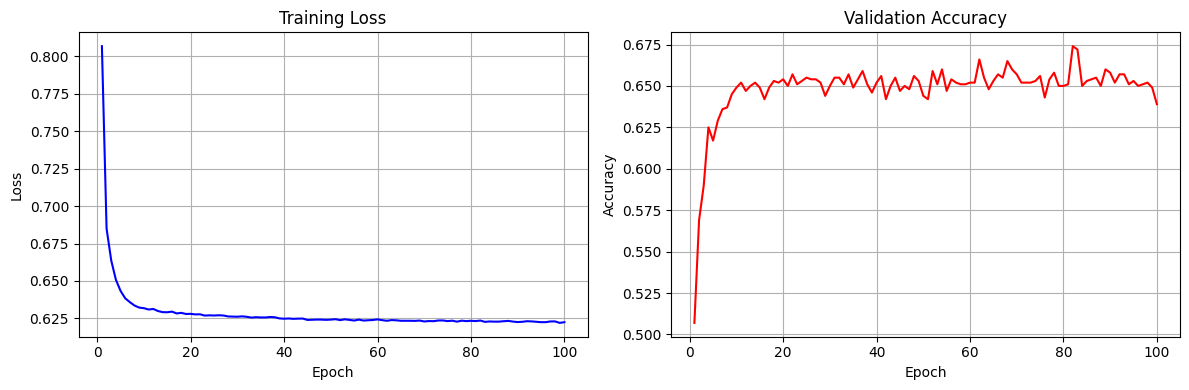

In [35]:
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt

input_dim = train_input.size(1)
model = LogisticRegression(input_dim, norm='l1')
lr = 0.005
num_epochs = 100
norm_weight = 0.0001

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)

train_losses = []
val_accuracies = []

for epoch in tqdm(range(num_epochs)):
    # 验证阶段
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            preds = model(inputs)
            predicted = (preds >= 0.5).float()
            val_total += labels.size(0)
            val_correct += (predicted.view(-1) == labels.view(-1)).sum().item()
    val_acc = val_correct / val_total
    val_accuracies.append(val_acc)

    # 训练阶段
    model.train()
    train_loss_sum = 0
    for inputs, labels in train_loader:
        preds = model(inputs)
        loss = criterion(preds, labels)
        if norm_weight != 0:
            loss = loss + model.normnize() * norm_weight
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()
    train_avg = train_loss_sum / len(train_loader)
    train_losses.append(train_avg)

    if epoch % 10 == 0:  # 每10轮打印一次，减少输出
        print(f"Epoch {epoch}: Loss={train_avg:.4f}, Val Acc={val_acc:.4f}")

# 绘制曲线并保存
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, num_epochs+1), train_losses, 'b-')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(range(1, num_epochs+1), val_accuracies, 'r-')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.grid(True)

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/loss_curve.png', dpi=150)
plt.show()

In [36]:
test_total = 0
test_correct = 0
for test_input, test_label in test_loader:
    model.eval()
    with torch.no_grad():
        test_pred = model(test_input)
        predicted = (test_pred >= 0.5).float()
        test_total += test_label.size(0)
        test_correct += (predicted.view(-1) == test_label.view(-1)).sum().item()
test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.634


## 实验收获与建议
- 收获：掌握了 pandas 数据清洗、PyTorch Dataset/DataLoader、逻辑回归原理及 L1/L2 正则化。
- 难度：数据清洗中最复杂的是 employmentLength 的正则匹配和日期差计算。
- 建议：可增加学习率衰减和早停，并绘制损失曲线。

In [37]:
# 诊断1：检查模型最终参数和预测分布
print("Final model bias b:", model.b.item())
print("Final model weight mean:", model.w.abs().mean().item())
print("Final weight std:", model.w.std().item())

# 在验证集上获取所有预测概率
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        preds = model(inputs)
        all_preds.append(preds)
        all_labels.append(labels)
all_preds = torch.cat(all_preds).view(-1)
all_labels = torch.cat(all_labels).view(-1)
print("Prediction probability mean:", all_preds.mean().item())
print("Prediction probability >0.5 ratio:", (all_preds > 0.5).float().mean().item())
print("True label mean:", all_labels.float().mean().item())

# 诊断2：用 sklearn 的逻辑回归测试数据本身是否可区分
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 使用原始 numpy 数据（注意 train_input, train_label 已经是 tensor）
X_train = train_input.numpy()
y_train = train_label.numpy().ravel()
X_val = val_input.numpy()
y_val = val_label.numpy().ravel()

sk_model = LogisticRegression(max_iter=1000, random_state=42)
sk_model.fit(X_train, y_train)
train_acc = sk_model.score(X_train, y_train)
val_acc = sk_model.score(X_val, y_val)
print(f"Sklearn LogisticRegression - Train acc: {train_acc:.4f}, Val acc: {val_acc:.4f}")

Final model bias b: -1.430343508720398
Final model weight mean: 0.5549347400665283
Final weight std: 0.9967296123504639
Prediction probability mean: 0.49220308661460876
Prediction probability >0.5 ratio: 0.4790000021457672
True label mean: 0.5049999952316284
Sklearn LogisticRegression - Train acc: 0.6535, Val acc: 0.6620
